Notebook to generate the figures in the readme.md

In [1]:
from viz import * 
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd 
import matplotlib as mpl
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
from shapely.geometry import Polygon, MultiPolygon
from textwrap import fill
from matplotlib.colors import TwoSlopeNorm
import dataframe_image as dfi
from textwrap import fill
import colorcet as cc
from aux_func import code_to_state, color_palette, estado_para_regiao, rename_models

# Definir a cor das bordas (spines) como cinza
mpl.rcParams['axes.edgecolor'] = 'gray'

# Definir a cor das linhas dos ticks maiores e menores como cinza
mpl.rcParams['xtick.color'] = 'gray'
mpl.rcParams['ytick.color'] = 'gray'
mpl.rcParams['xtick.labelcolor'] = 'black'
mpl.rcParams['ytick.labelcolor'] = 'black'
plt.rcParams['axes.labelsize'] = 16 # Axis labels
plt.rcParams['xtick.labelsize'] = 14  # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 14  # Y-axis tick labels
plt.rcParams['font.size'] = 16  # General font size
FONT = 12

In [2]:
challenge = 'dengue_state'

df_preds = pd.read_csv(f'./predictions/predictions_all_models_{challenge}.csv.gz', index_col = 'Unnamed: 0')
df_preds.date = pd.to_datetime(df_preds.date)
df_preds.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,adm_1,id,validation,wis,model
0,2022-10-09,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
1,2022-10-16,37.019327,43.295517,51.743385,66.653189,83.207109,100.790847,116.992117,126.864602,134.406880,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
2,2022-10-23,55.945220,68.411390,84.200302,108.887826,135.698419,163.344639,189.017119,205.765306,218.575663,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
3,2022-10-30,58.185781,69.697014,83.792687,107.076328,132.601767,158.745145,184.276095,201.204977,212.912726,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
4,2022-11-06,58.634062,68.591352,80.855678,101.969117,125.548661,150.259612,174.517426,190.524410,202.512661,12,6822,1,95.67,3rd_imdc_isi_isi-dengue


In [3]:
df_rank = pd.read_csv('predictions/rank_ratio.csv.gz')

df_rank['model'] = df_rank['model'].replace(rename_models)

df_rank['rank'] = df_rank.groupby(['validation', 'adm_1'])['wis_ratio'].rank(ascending=True, method='min')
#df_rank['region'] = df_rank['region'].replace(rename_regions)

df_rank.head()

,model,adm_1,validation,wis,wis_baseline,wis_ratio,region,rank
0,UNIFESP,11,1,205.38,101.894535,2.015613,North,24.0
1,UNIFESP,11,2,68.46,31.277812,2.188772,North,20.0
2,UNIFESP,11,3,30.97,24.740000,1.251819,North,19.0
3,UNIFESP,11,4,42.33,26.550000,1.594350,North,18.0
4,UNIFESP,12,1,37.72,30.964984,1.218150,North,14.0


## Plot overall performance:

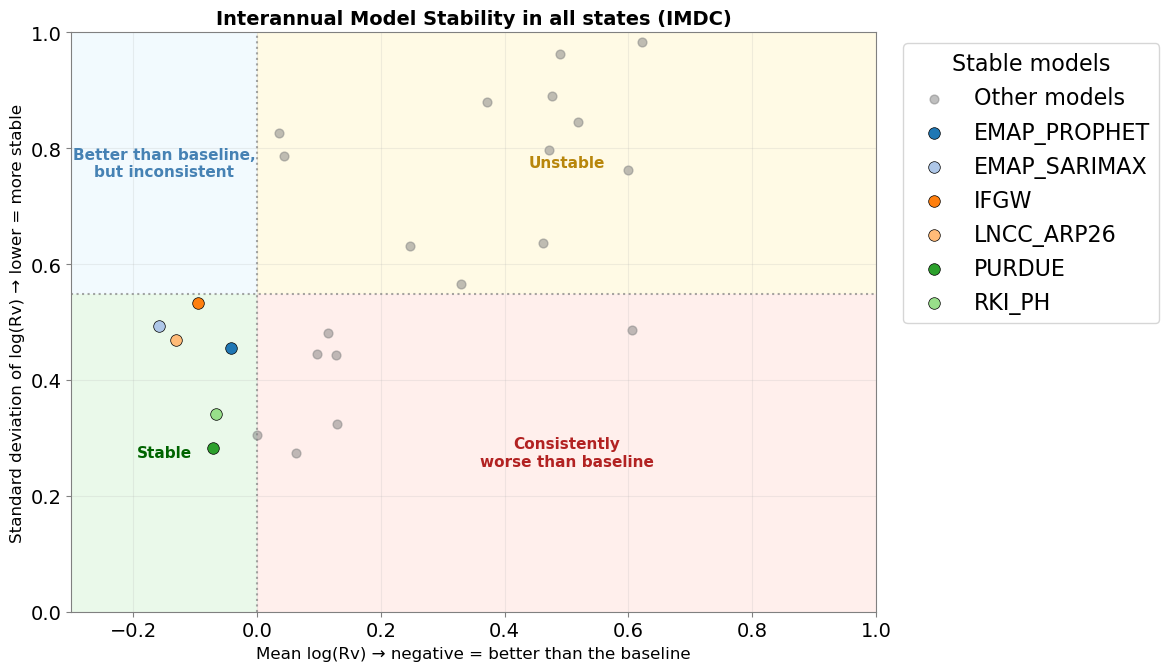

In [6]:
fig, ax, df_agg = plot_model_scatter(
    df_rank,
    rename_models=rename_models,
    baseline_model="PROCC",
    exclude_adm1=32,
    title="Interannual Model Stability in all states (IMDC)",
    xlabel="Mean log(Rv) → negative = better than the baseline",
    ylabel="Standard deviation of log(Rv) → lower = more stable",
    xlim=(-0.3, 1),
    ylim=(0, 1),
    figsize=(12, 7),
    savepath=f'figures/scatter_stable_{challenge}.png',)

## Plots Best models by state: 

In [5]:
df_summary = (
    df_rank
    .groupby(["adm_1", "model"], as_index=False)
    .agg(
        geometric_mean_ratio=("wis_ratio", lambda x: np.exp(np.mean(np.log(x)))),
    )
    .sort_values(["adm_1", "geometric_mean_ratio"])
)

column = 'geometric_mean_ratio'

df_summary["rank"] = (
    df_summary.groupby(["adm_1"])[[column]].rank(method="min", ascending=True)
)


df_bm_st = df_summary.loc[df_summary['rank'] ==1].rename(columns = {'model': 'best_model'})
df_bm_st['state'] = df_bm_st['adm_1'].replace(code_to_state)

df_bm_st.head()

,adm_1,best_model,geometric_mean_ratio,rank,state
9,11,EMAP_SARIMAX,0.769598,1.0,RO
48,12,PURDUE,0.940250,1.0,AC
74,13,PUCRIO,0.816319,1.0,AM
90,14,EMAP_SARIMAX,0.886171,1.0,RR
128,15,PUCRIO,0.861798,1.0,PA


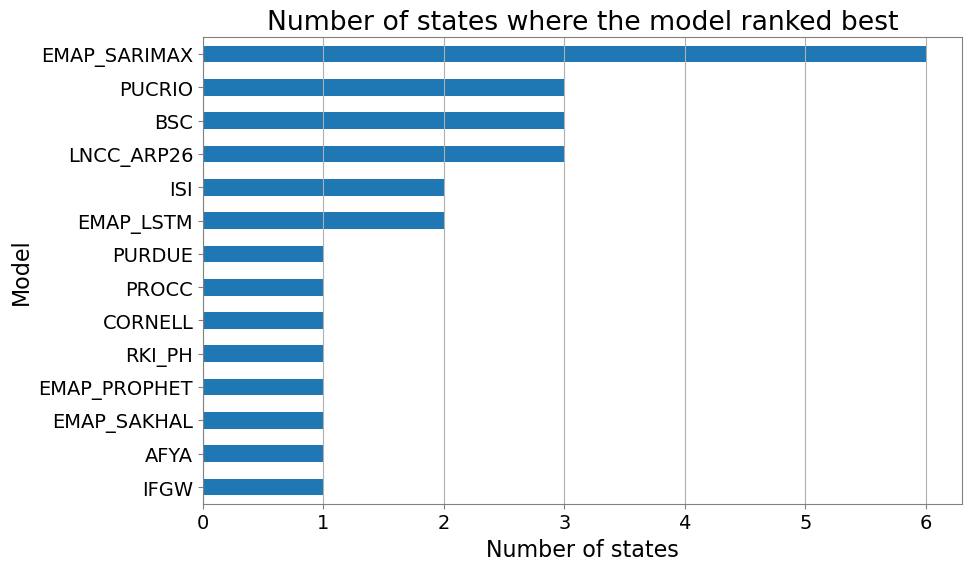

In [6]:
barplot_best_models(
    df_bm_st,
    challenge=challenge,
    model_col="best_model") 

Plot map: 

In [34]:
def remove_holes(geom):
    if geom.geom_type == "Polygon":
        return Polygon(geom.exterior)  # mantém só o contorno externo
    elif geom.geom_type == "MultiPolygon":
        # acessa cada polígono dentro do MultiPolygon
        return MultiPolygon([Polygon(p.exterior) for p in geom.geoms])
    else:
        return geom

In [35]:
df_muni = gpd.read_file('../imdc_2026/data/shape_muni.gpkg')

df_muni["geometry"] = df_muni.buffer(0)

df_uf = df_muni.dissolve(by="uf")

df_uf["geometry"] = df_uf["geometry"].apply(remove_holes)

df_uf["geometry"] = df_uf.buffer(1e-9).buffer(-1e-9)

# reset index if you want 'uf' back as a column
df_uf = df_uf.reset_index()

df_uf_m = df_uf.merge(df_bm_st, left_on = 'uf', right_on = 'state')

df_uf_m.head()

/tmp/ipykernel_61927/1175374976.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df_uf["geometry"] = df_uf.buffer(1e-9).buffer(-1e-9)


,uf,geometry,geocode,geocode_name,uf_code,adm_1,best_model,geometric_mean_ratio,rank,state
0,AC,"POLYGON ((-70.51515 -7.79238, -70.05498 -7.845...",1200013,Acrelândia,12,12,PURDUE,0.940250,1.0,AC
1,AL,"MULTIPOLYGON (((-38.23759 -9.3298, -38.23759 -...",2700102,Água Branca,27,27,BSC,0.582970,1.0,AL
2,AM,"POLYGON ((-72.37321 -4.83344, -72.37321 -4.833...",1300029,Alvarães,13,13,PUCRIO,0.816319,1.0,AM
3,AP,"MULTIPOLYGON (((-54.87625 2.42669, -54.87625 2...",1600055,Serra do Navio,16,16,BSC,0.731751,1.0,AP
4,BA,"MULTIPOLYGON (((-46.57715 -11.36086, -46.57715...",2900108,Abaíra,29,29,ISI,0.711791,1.0,BA


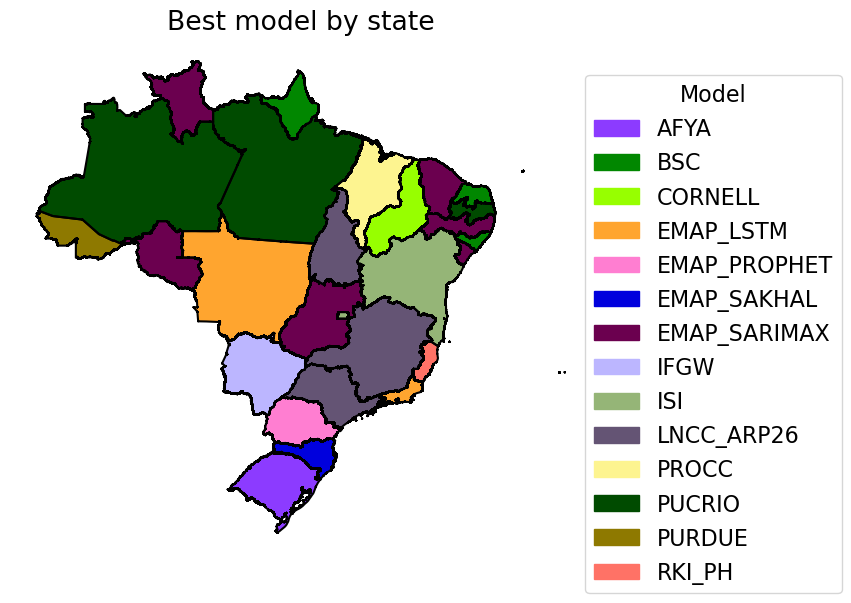

In [36]:
_, ax = plt.subplots(figsize = (7.5, 7.5))

handles = []  # aqui guardamos os patches da legenda

for model in np.sort(df_uf_m.best_model.unique()): 

    df_ = df_uf_m.loc[df_uf_m.best_model == model]
    
    #model = df_.best_model.values[0]

    df_.plot(color = color_palette[model], label = model, ax=ax)

    if not any(h.get_label() == model for h in handles):
        handles.append(mpatches.Patch(color=color_palette[model], label=model))

df_uf.boundary.plot(ax=ax, color = 'black')
ax.axis('off')

ax.legend(handles = handles, title = 'Model', bbox_to_anchor = (1.45, 0.95))

ax.set_title('Best model by state')

plt.savefig(f'figures/map_best_model_{challenge}.png', dpi = 400, bbox_inches = 'tight')
plt.show()

### Best model by region:

In [37]:
df_best_region_model = df_rank.groupby(["region", "model"], as_index=False).agg(
        arithmetic_mean_ratio=("wis_ratio", "mean"),
        geometric_mean_ratio=("wis_ratio", lambda x: np.exp(np.mean(np.log(x)))),
    ).sort_values(["region", "geometric_mean_ratio"]) 


df_best_region_model["rank"] = (
    df_best_region_model.groupby(["region"])[[column]].rank(method="min", ascending=True)
)

df_best_region_model.head()

,region,model,arithmetic_mean_ratio,geometric_mean_ratio,rank
9,Midwest,EMAP_SARIMAX,0.891826,0.804123,1.0
13,Midwest,IFGW,0.996070,0.838807,2.0
23,Midwest,RKI_PH,0.947156,0.892820,3.0
21,Midwest,PURDUE,0.939682,0.894167,4.0
20,Midwest,PUCRIO,1.178763,0.947244,5.0


### PLot Medal Board: 

In [38]:
df_top_3 = df_summary.loc[df_summary['rank'].isin([1, 2, 3])]
df_top_3['state'] = df_top_3['adm_1'].replace(code_to_state)

df_top_3.head()

,adm_1,model,geometric_mean_ratio,rank,state
9,11,EMAP_SARIMAX,0.769598,1.0,RO
20,11,PUCRIO,0.789304,2.0,RO
15,11,LNCC_ARP26,0.800598,3.0,RO
48,12,PURDUE,0.940250,1.0,AC
47,12,PUCRIO,0.969428,2.0,AC


In [39]:
ranked_models = df_top_3.pivot(index='rank', columns='state', values='model')

ranked_models.head()

state,AC,AL,AM,AP,BA,CE,DF,ES,GO,MA,...,PR,RJ,RN,RO,RR,RS,SC,SE,SP,TO
rank,,,,,,,,,,,,,,,,,,,,,
1.0,PURDUE,BSC,PUCRIO,BSC,ISI,EMAP_SARIMAX,ISI,RKI_PH,EMAP_SARIMAX,PROCC,...,EMAP_PROPHET,EMAP_LSTM,BSC,EMAP_SARIMAX,EMAP_SARIMAX,AFYA,EMAP_SAKHAL,EMAP_SARIMAX,LNCC_ARP26,LNCC_ARP26
2.0,PUCRIO,EMAP_SARIMAX,PROCC,EMAP_XGB,IFGW,ISI,IFGW,CORNELL,EMAP_LSTM,PUCRIO,...,CERI,RKI_LSTM,PUCRIO,PUCRIO,PROCC,EMAP_PROPHET,AFYA,LNCC_ARP26,PUCRIO,EMAP_SARIMAX
3.0,PROCC,IFGW,IFGW,IFGW,LNCC_ARP26,LNCC_ARP26,RKI_LSTM,PROCC,PROCC,CORNELL,...,EMAP_XGB,PUCRIO,EMAP_SARIMAX,LNCC_ARP26,IFGW,RKI_PH,UNESP,IFGW,EMAP_SAKHAL,EMAP_LSTM


In [41]:

order = {
    'south': ['PR', 'SC' ,'RS'],
    'southeast': ['MG', 'RJ', 'SP'],
    'midwest': ['DF', 'GO', 'MT', 'MS'],
    'northeast': ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE'],
    'north': ['AC', 'AM', 'AP', 'PA', 'RO', 'RR', 'TO'] } 

In [ ]:
for region in order.keys(): 
    styler = plot_medal_board(ranked_models[order[region]],) 
    dfi.export(styler, f"figures/medals_{region}.png", dpi = 400,  table_conversion="matplotlib",
)

### Models with mean ratio >1 

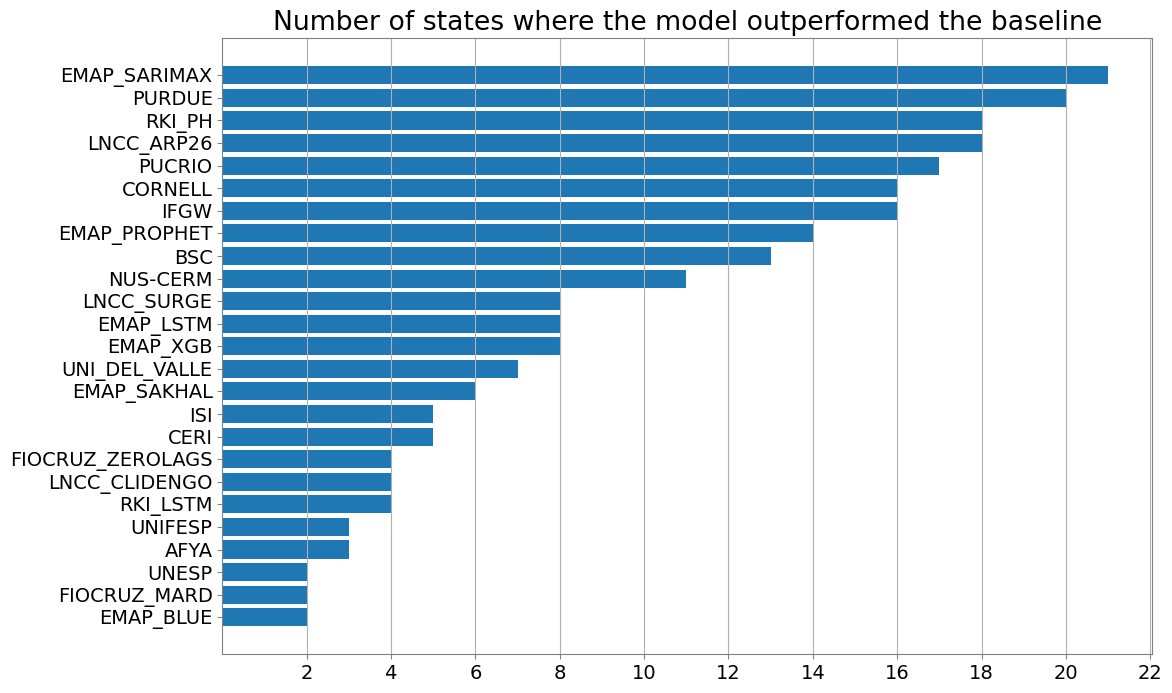

In [43]:
df_agg = df_summary.loc[df_summary.geometric_mean_ratio < 1].groupby(['model'])[['adm_1']].count()
df_agg = df_agg.sort_values(by = 'adm_1')

_, ax= plt.subplots(figsize = (12, 8))

ax.barh(df_agg.index, df_agg.adm_1)

ax.grid(axis = 'x')
ax.set_title('Number of states where the model outperformed the baseline')
ax.set_xticks(np.arange(2, 23, step = 2))

plt.savefig(f'figures/n_states_out_base_by_model_{challenge}.png', dpi = 400)

plt.show()

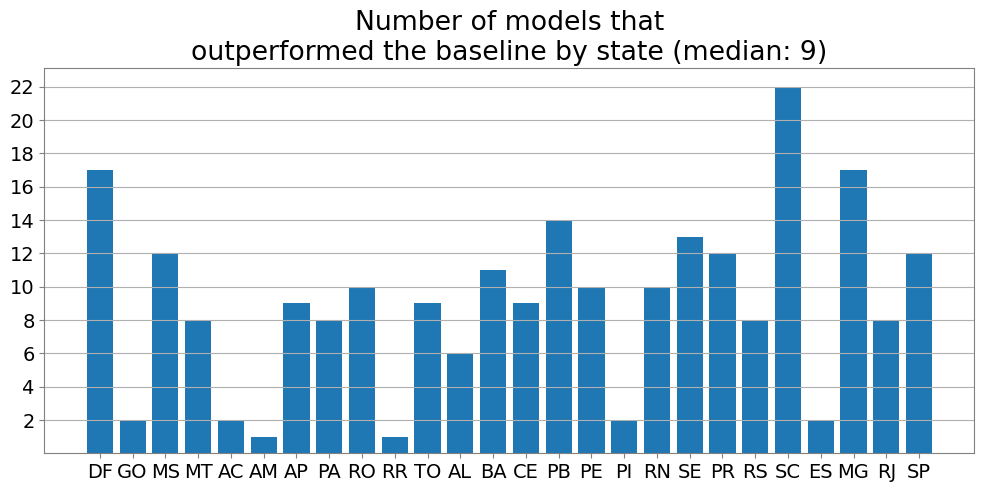

In [44]:
df_agg = df_summary.loc[df_summary.geometric_mean_ratio < 1].groupby(['adm_1'])[['model']].count().reset_index()
df_agg['adm_1'] = df_agg['adm_1'].replace(code_to_state)

# Cria a coluna de região e ordena
df_agg['regiao'] = df_agg['adm_1'].map(estado_para_regiao)
df_agg = df_agg.sort_values(by=['regiao', 'adm_1'])

# Plotagem
_, ax = plt.subplots(figsize=(12, 5))
ax.bar(df_agg.adm_1, df_agg.model)
ax.set_title(f'Number of models that\noutperformed the baseline by state (median: {int(np.median(df_agg.model))})')
ax.set_yticks(np.arange(2, 23, step = 2))

ax.grid(axis='y')

plt.savefig(f'figures/n_models_out_base_by_state_{challenge}.png', dpi = 400)

### Heatmaps

In [46]:
for region in order.keys(): 
    plot_geometric_ratio_heatmap(
        df_summary,
        code_to_state,
        order[region],
        region,
        figsize=(25, 5),
    )

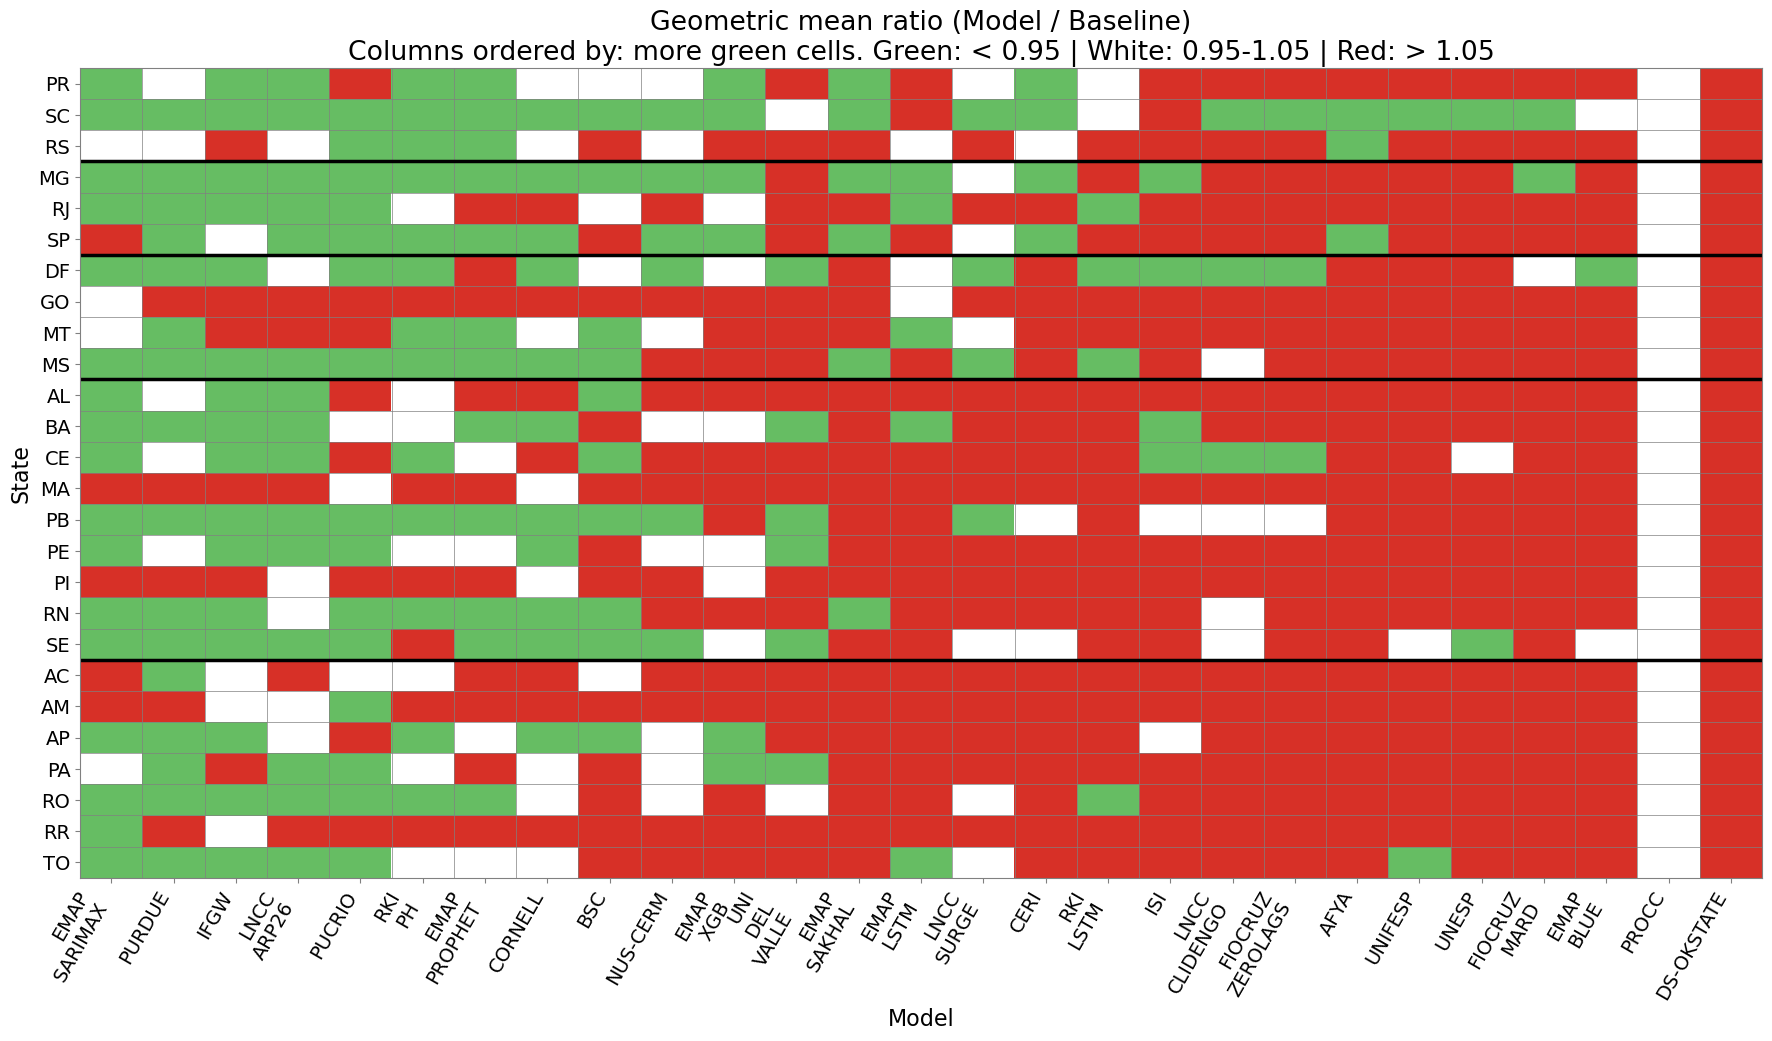

In [48]:
ranking = plot_matrix(df_summary, code_to_state, [ 'PR', 'SC' ,'RS',
            'MG', 'RJ', 'SP',
            'DF', 'GO', 'MT', 'MS',
            'AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE',
            'AC', 'AM', 'AP', 'PA', 'RO', 'RR', 'TO'],
        figsize=(18, 15),)


### Rankplots: 

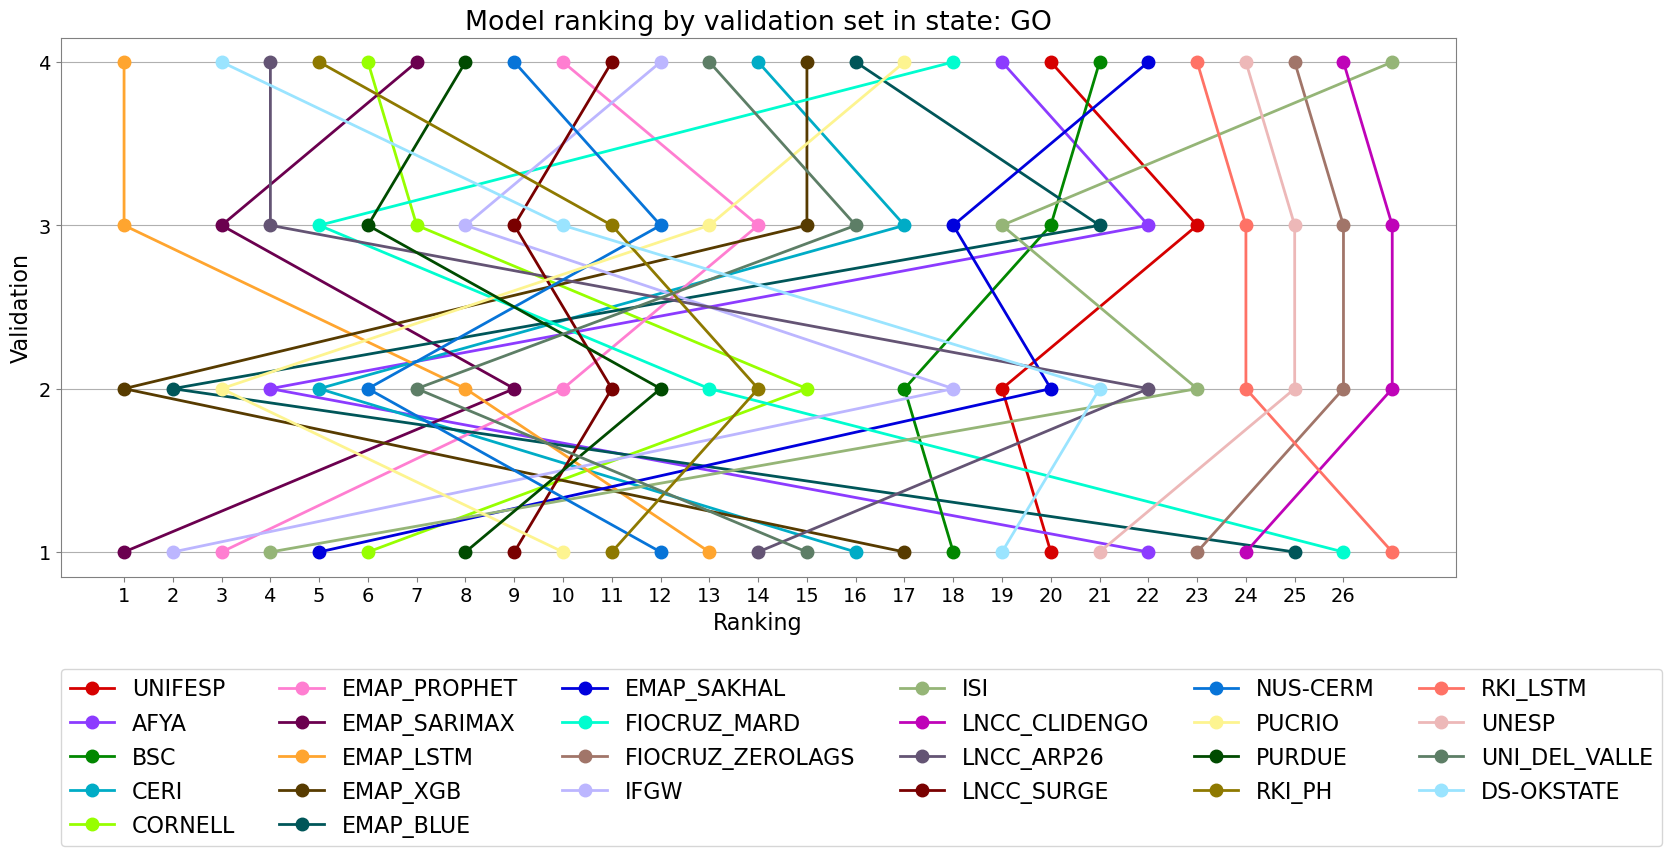

In [ ]:
state = 52
plot_rankplot(
    df=df_rank.loc[df_rank.model !='PROCC'],
    colors=color_palette,
    x_col="rank",
    x_label="Ranking",
    title="Model ranking by validation set",
    state=state,
    x_ticks=np.arange(1, 27),
    x_lim=None,
        ncols_legend=6,
        bbox_to_anchor=(0.5, -0.25), 
        challenge = challenge,
        code_to_state = code_to_state
)

### Violin plots

/tmp/ipykernel_97937/1943320770.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


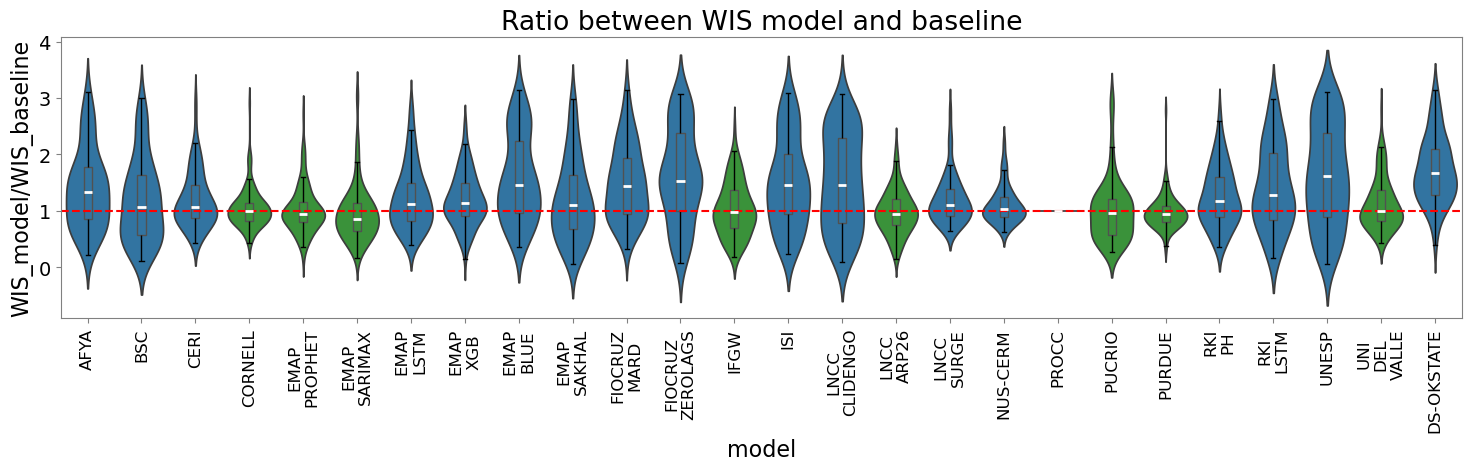

(<Figure size 1500x500 with 1 Axes>,
 <Axes: title={'center': 'Ratio between WIS model and baseline'}, xlabel='model', ylabel='WIS_model/WIS_baseline'>)

In [ ]:
plot_violin(df_rank, region = None)

/tmp/ipykernel_97937/1943320770.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


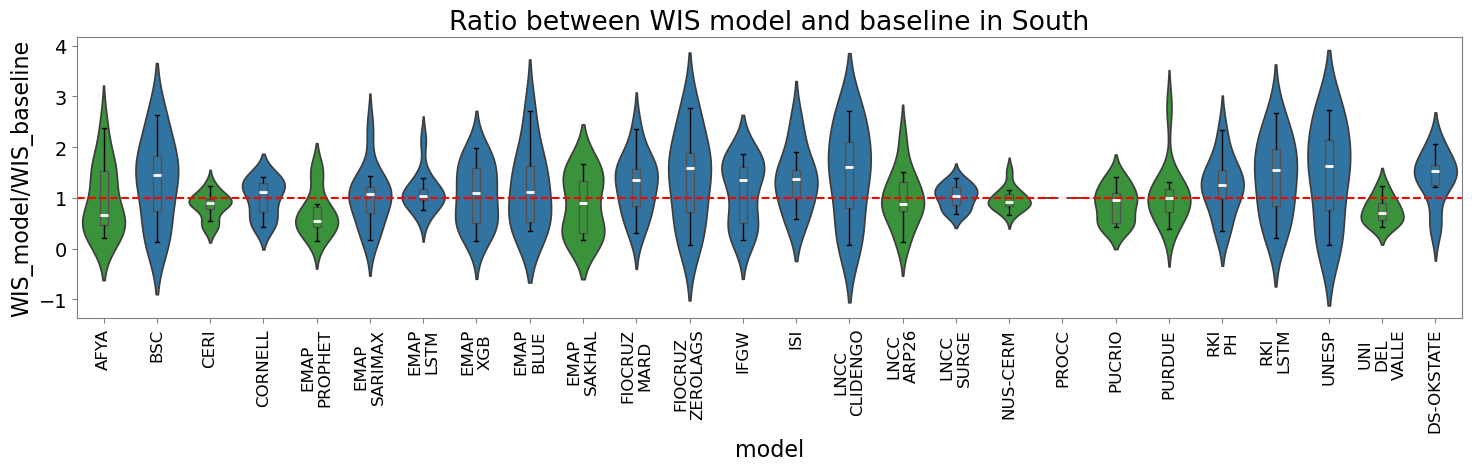

/tmp/ipykernel_97937/1943320770.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


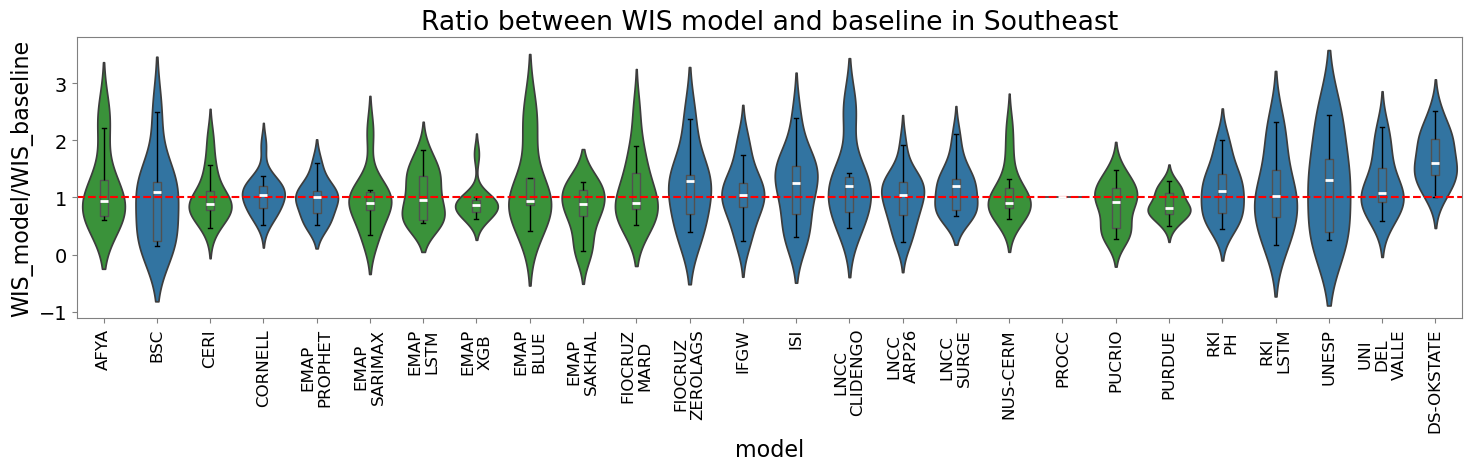

/tmp/ipykernel_97937/1943320770.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


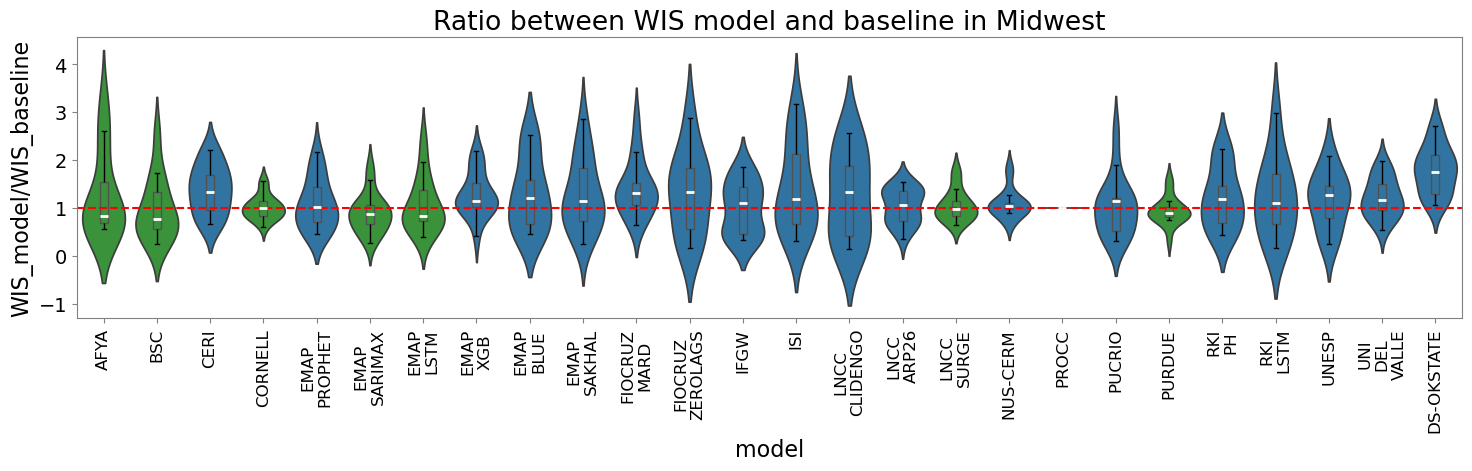

/tmp/ipykernel_97937/1943320770.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


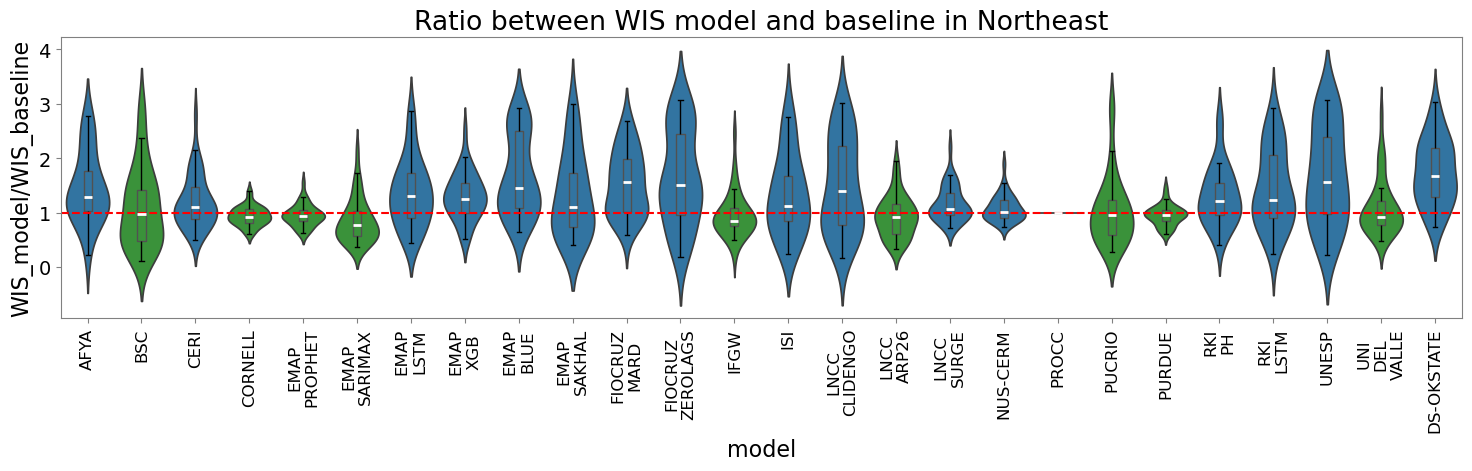

/tmp/ipykernel_97937/1943320770.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


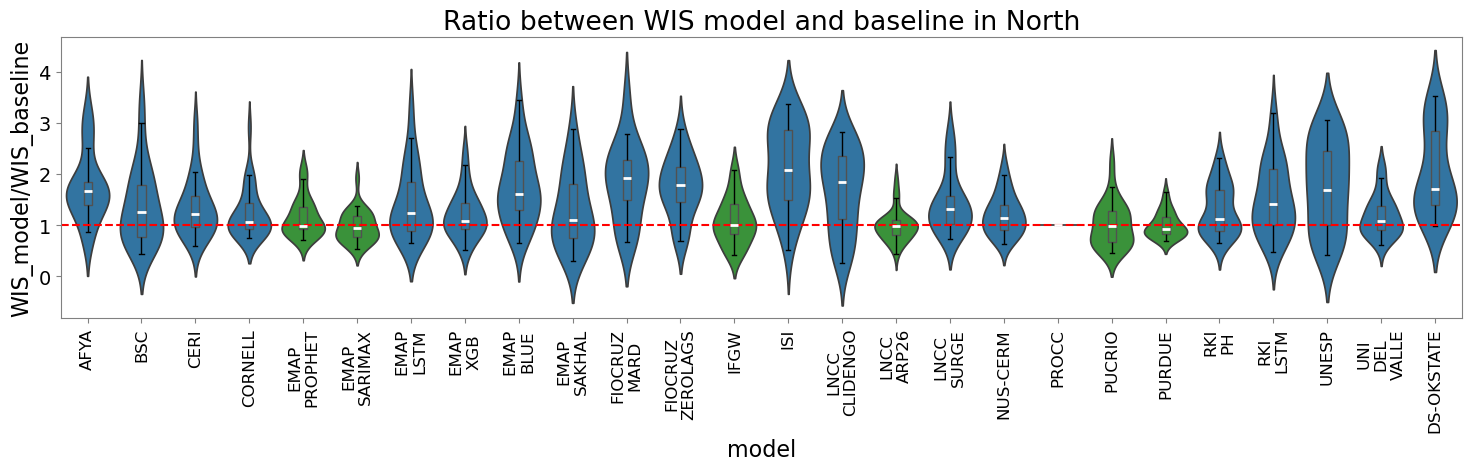

(<Figure size 1500x500 with 1 Axes>,
 <Axes: title={'center': 'Ratio between WIS model and baseline in North'}, xlabel='model', ylabel='WIS_model/WIS_baseline'>)

In [ ]:
plot_violin(df_rank, region = 'South')
plot_violin(df_rank, region = 'Southeast')
plot_violin(df_rank, region = 'Midwest')
plot_violin(df_rank, region = 'Northeast')
plot_violin(df_rank, region = 'North')

### Comp distributions - max cases, peak cases and peak height:

In [ ]:
df_true_params = pd.read_csv('data/parameters_dengue_state.csv.gz')

df_true_params.head()

,state,validation,peak_week,total_cases,peak_height,peak_height_model,t_ini
0,11,1,17.912460,13281,864,750.147209,1
1,11,2,20.624851,5583,604,424.351398,6
2,11,3,28.967172,2553,142,113.486196,1
3,11,4,23.444633,1472,72,64.545081,1
4,12,1,22.992623,4735,288,236.612882,1


In [ ]:
df_pars = pd.read_csv('predictions/new_metrics_dengue_state.csv.gz')
df_pars['model'] = df_pars['model'].replace(rename_models)
df_pars.head()

,model,validation,state,season_total_p25,season_total_p50,season_total_p975,season_peak_p25,season_peak_p50,season_peak_p975,r0_dist_p25,...,r0_dist_p975,pico_dist_p25,pico_dist_p50,pico_dist_p975,t_ini_dist_p25,t_ini_dist_p50,t_ini_dist_p975,max_c_dist_p25,max_c_dist_p50,max_c_dist_p975
0,ISI,2,12,8155.220843,9666.404427,11588.776658,225.289613,295.884608,419.352327,1.255347,...,1.304268,29.934870,31.934181,35.000000,1.0,1.0,1.000,221.703746,271.983601,316.168189
1,ISI,3,12,5296.213880,6433.353223,7836.201734,148.828929,190.215776,248.274815,1.259569,...,1.288510,29.806261,32.044642,34.895799,1.0,1.0,1.000,141.684160,175.709042,209.287538
2,ISI,4,12,7235.298114,8421.714410,9572.018224,199.337666,244.680701,301.015333,1.259767,...,1.289039,30.060873,31.744612,34.252873,1.0,1.0,1.000,199.472020,222.530214,257.894208
3,PURDUE,2,12,2120.596418,6765.841749,28221.394693,144.663450,611.092154,4306.154039,1.109418,...,2.135155,7.888542,18.482081,33.183729,1.0,1.0,5.525,74.984244,386.932102,2199.990377
4,PURDUE,3,12,1518.752445,5766.735068,25714.256030,98.427024,478.604529,3005.435595,1.236723,...,2.050592,11.531725,19.721003,31.194712,1.0,1.0,5.525,54.121028,342.182133,1735.561044


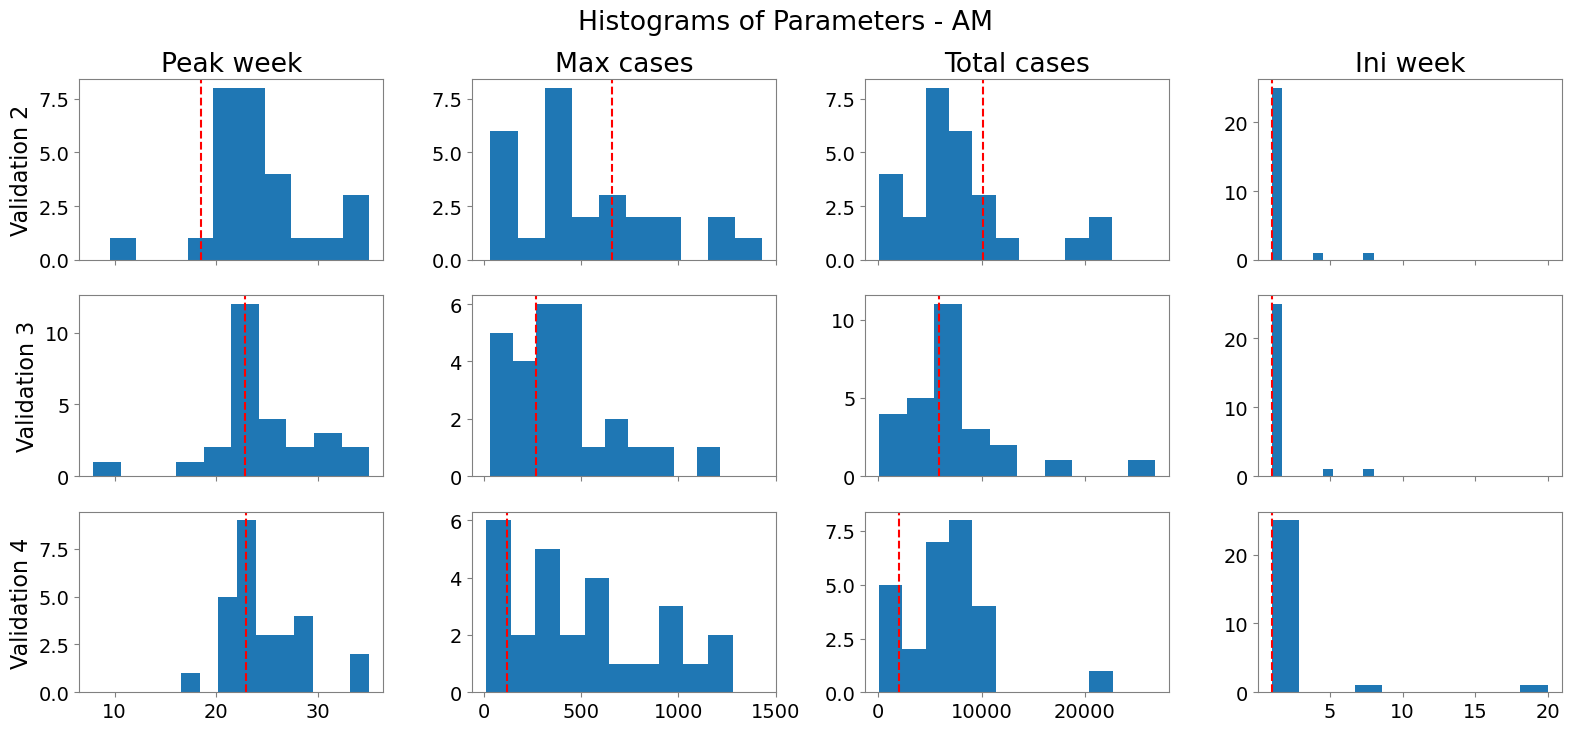

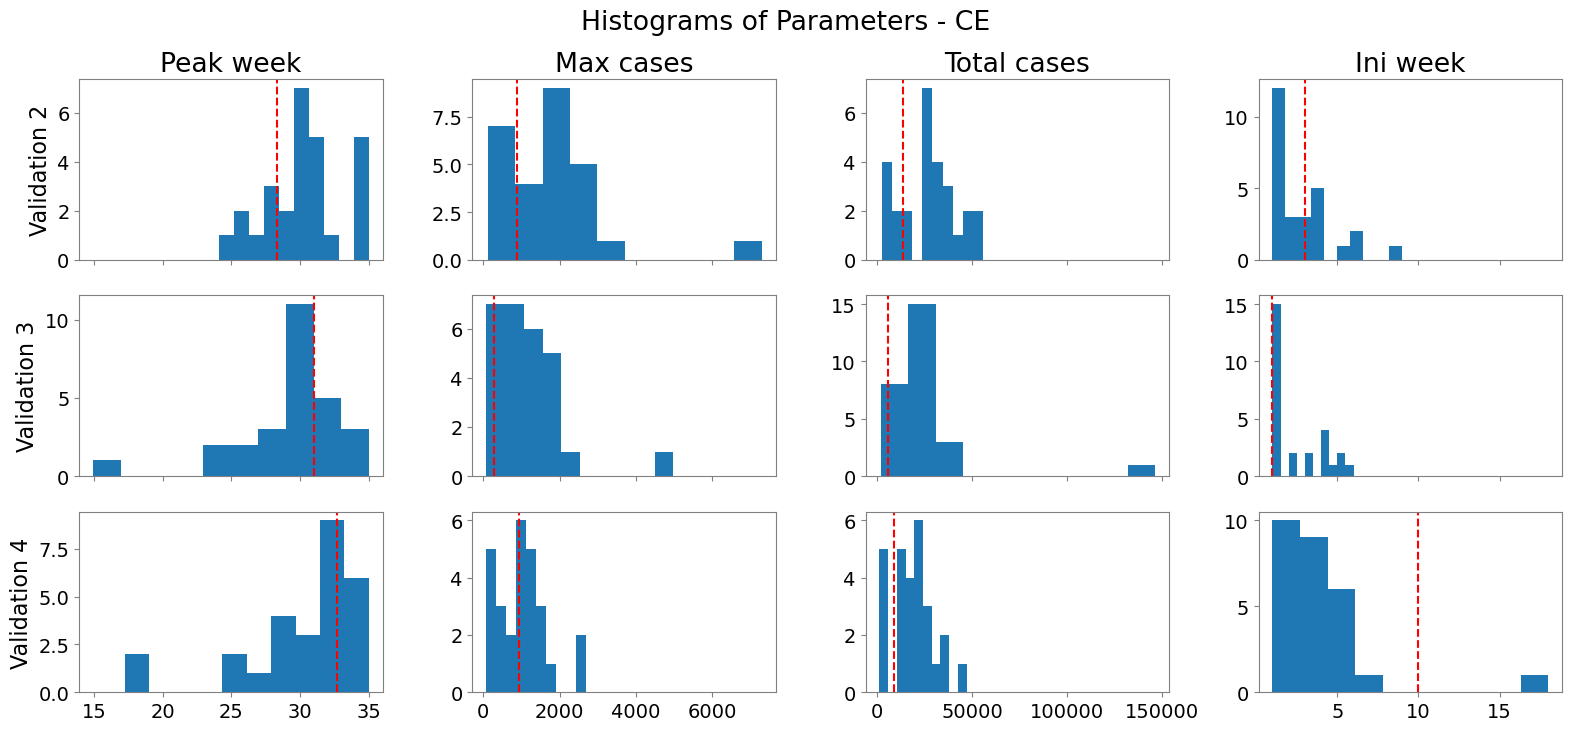

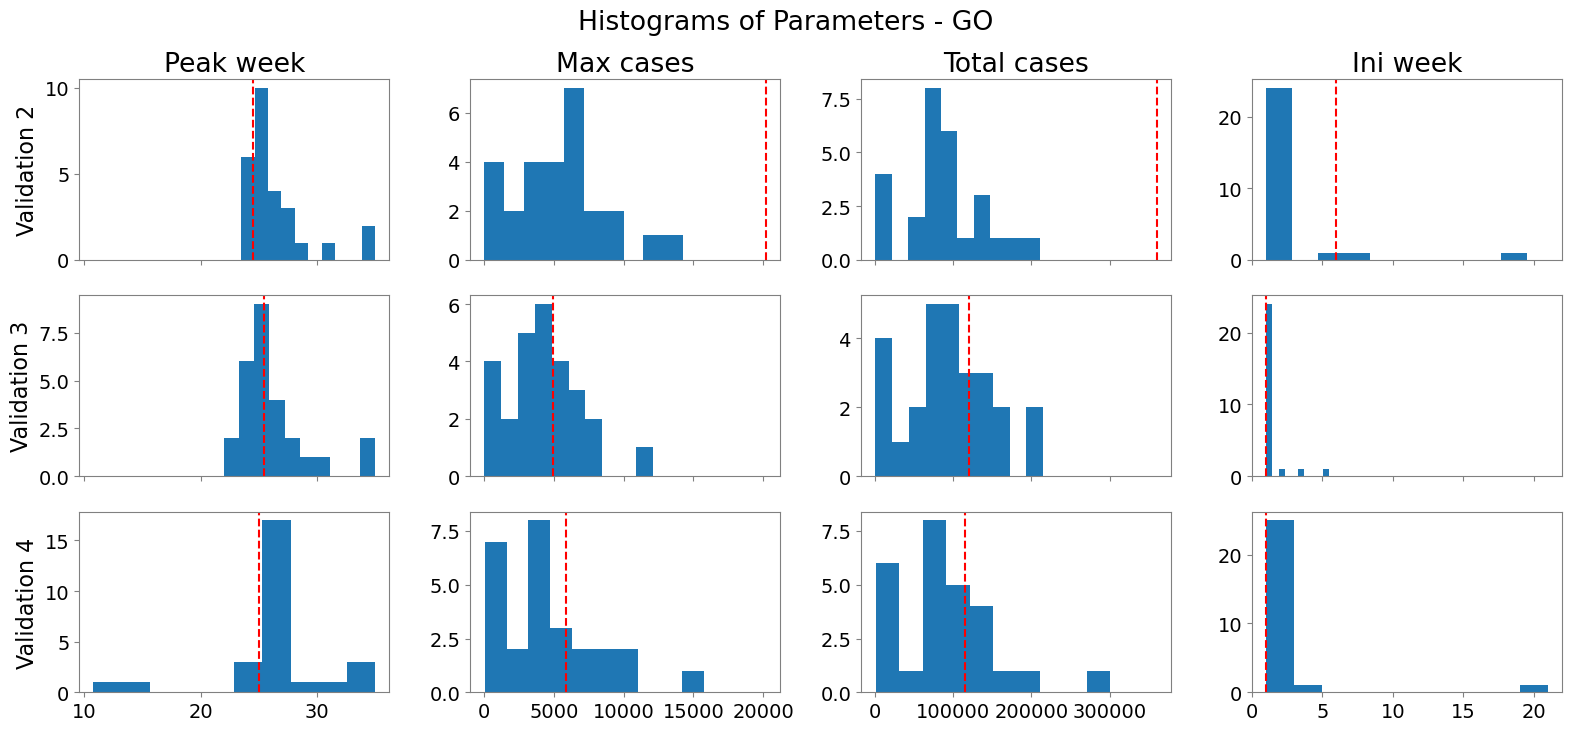

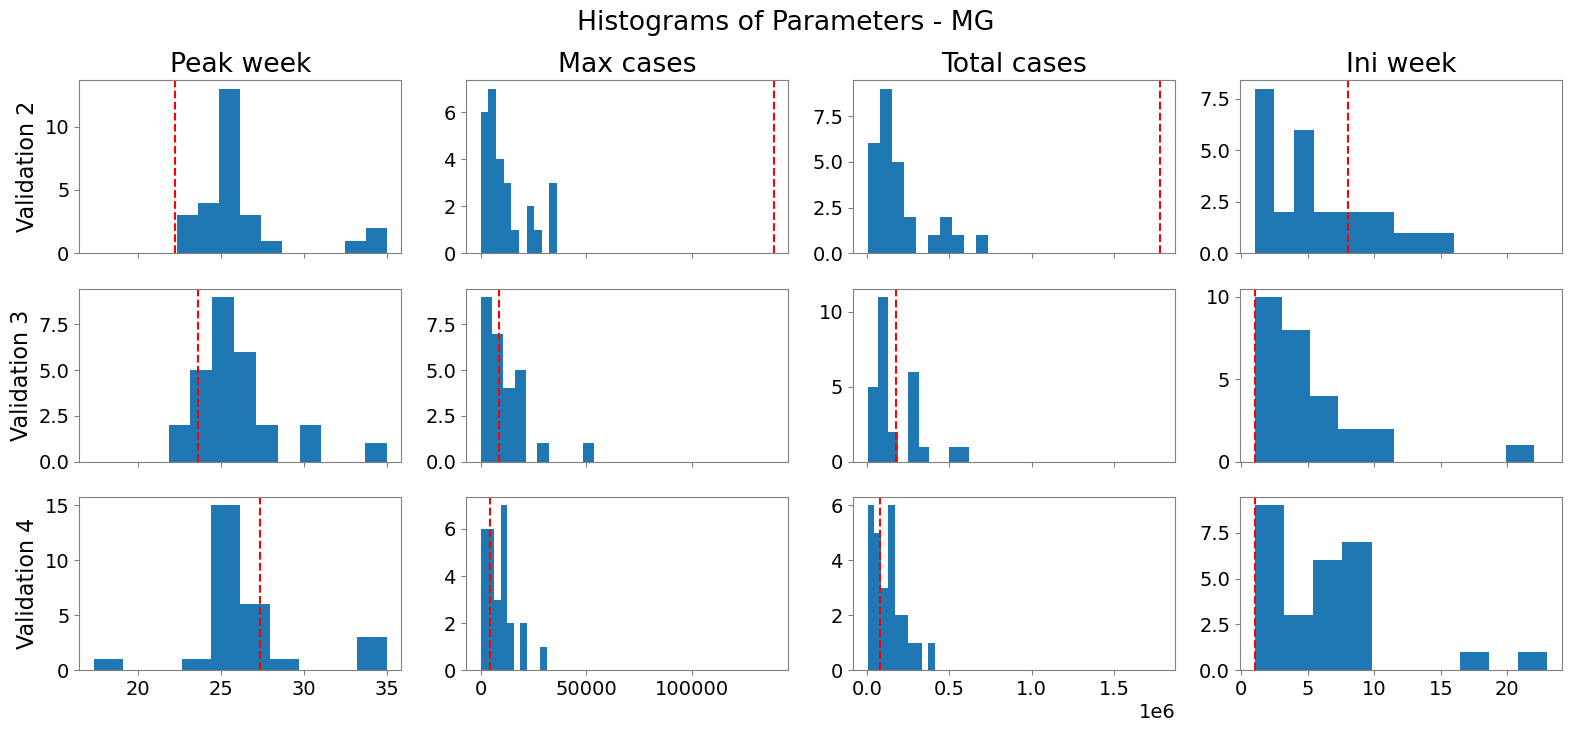

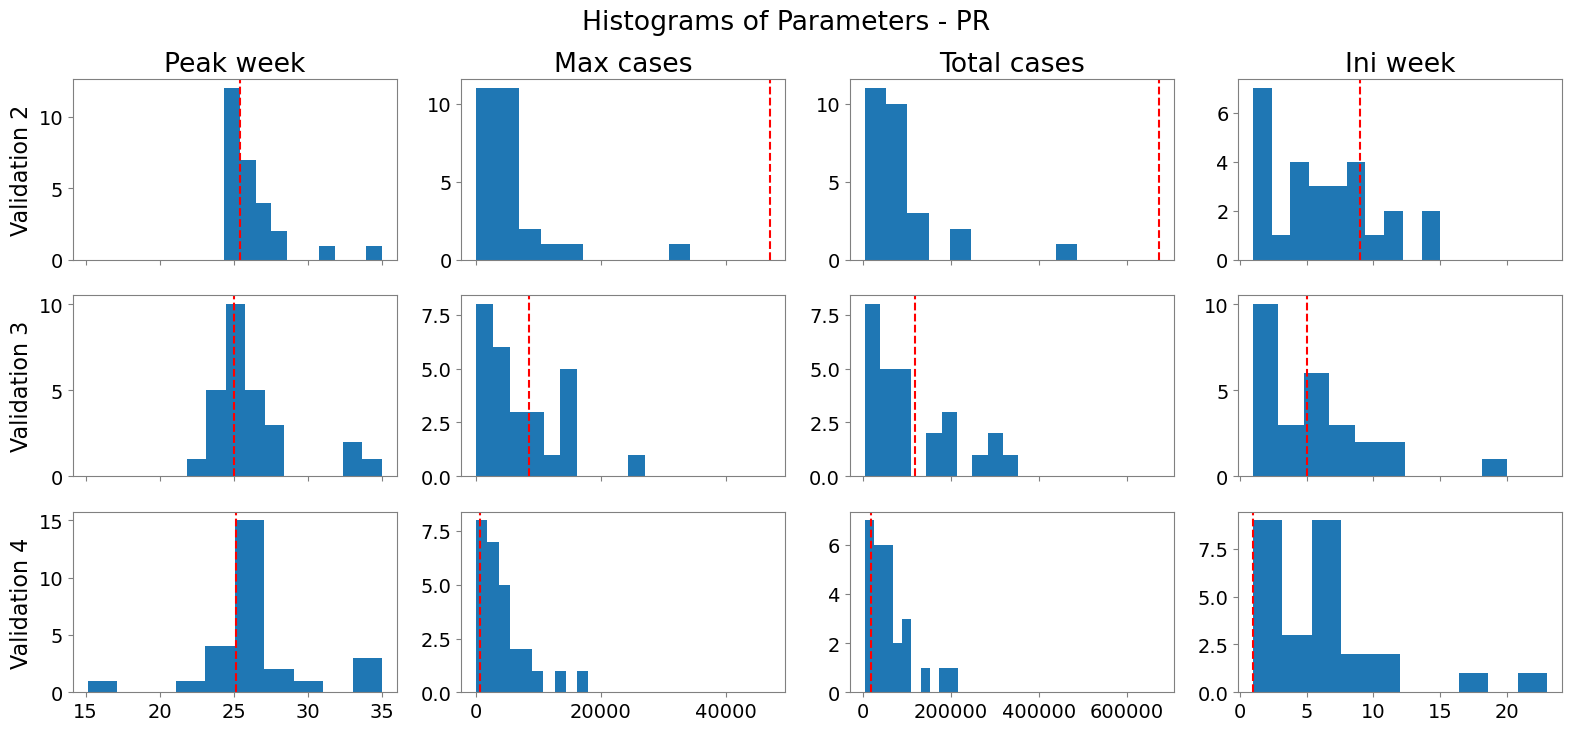

In [ ]:
for state in [13, 23, 52, 31, 41 ]:

    fig, ax = plot_parameter_histograms(df_true_params,
        df_pars,
        state =state, code_to_state=code_to_state)
    
    plt.savefig(f'figures/hist_pars_{state}_{challenge}.png', dpi = 400, bbox_inches = 'tight')
    

In [ ]:
adm_1 = 33 
validation = 2

for adm_1 in df_pars.state.unique(): 

    for validation in [2,3,4]: 

        _,ax = plt.subplots(4,1, figsize = (15, 9), sharex= True)


        plot_par_bar(ax[0], 'peak_week', adm_1, validation, df_pars, df_true_params)

        plot_par_bar(ax[1], 't_ini', adm_1, validation, df_pars, df_true_params)

        plot_par_bar(ax[2], 'peak_height', adm_1, validation, df_pars, df_true_params)

        plot_par_bar(ax[3], 'total_cases', adm_1, validation, df_pars, df_true_params)

        labels = [tick.get_text() for tick in ax[3].get_xticklabels()]

        labels = [label.replace("_", "\n", 1) for label in labels]
        ax[3].set_xticklabels(labels)

        ax[3].tick_params(axis='x', labelrotation=90)

        plt.savefig(f'figures/bar_pars_{adm_1}_{validation}_{challenge}.png', dpi = 300, bbox_inches = 'tight')

        plt.close()

/tmp/ipykernel_85759/4058111792.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[3].set_xticklabels(labels)
/tmp/ipykernel_85759/4058111792.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[3].set_xticklabels(labels)
/tmp/ipykernel_85759/4058111792.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[3].set_xticklabels(labels)
/tmp/ipykernel_85759/4058111792.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[3].set_xticklabels(labels)
/tmp/ipykernel_85759/4058111792.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[3].set_xticklabels(labels)
/tmp/